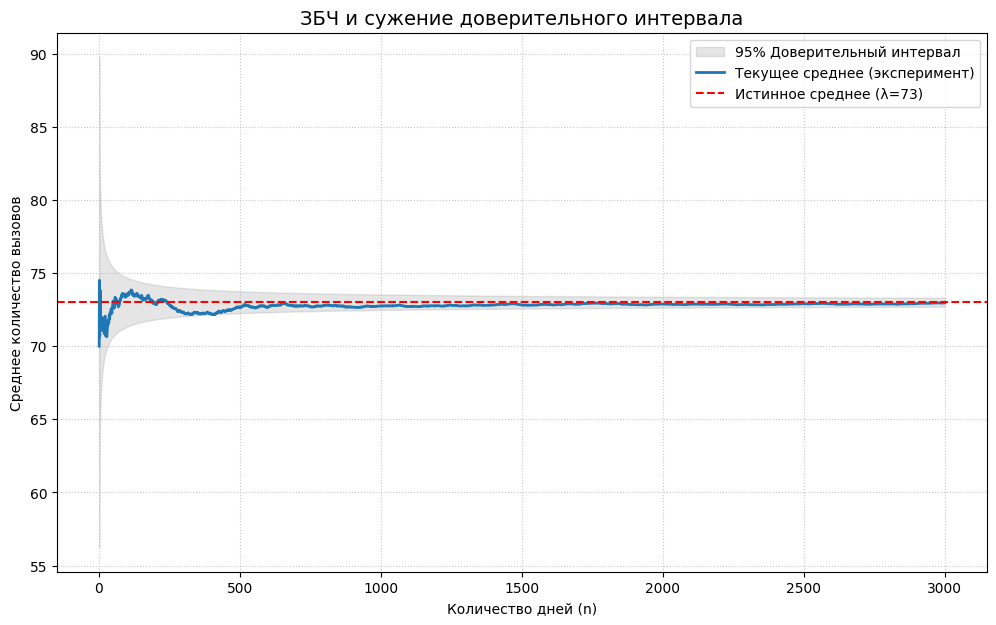

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры
lam = 73
days = 3000  # Увеличим интервал для большей наглядности
z_score = 1.96  # Для 95% доверительного интервала

# 1. Симуляция
np.random.seed(42) # Фиксируем для повторяемости
calls = np.random.poisson(lam, days)

# 2. Расчеты
cumulative_days = np.arange(1, days + 1)
cumulative_avg = np.cumsum(calls) / cumulative_days

# Стандартное отклонение для распределения Пуассона равно sqrt(lambda)
# Ошибка среднего (standard error) = sigma / sqrt(n)
std_error = np.sqrt(lam) / np.sqrt(cumulative_days)
upper_bound = lam + z_score * std_error
lower_bound = lam - z_score * std_error

# 3. Визуализация
plt.figure(figsize=(12, 7))

# Область доверительного интервала
plt.fill_between(cumulative_days, lower_bound, upper_bound, color='gray', alpha=0.2, label='95% Доверительный интервал')

# Линии
plt.plot(cumulative_days, cumulative_avg, color='#1f77b4', lw=2, label='Текущее среднее (эксперимент)')
plt.axhline(y=lam, color='red', linestyle='--', label=f'Истинное среднее (λ={lam})')

plt.title('ЗБЧ и сужение доверительного интервала', fontsize=14)
plt.xlabel('Количество дней (n)')
plt.ylabel('Среднее количество вызовов')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

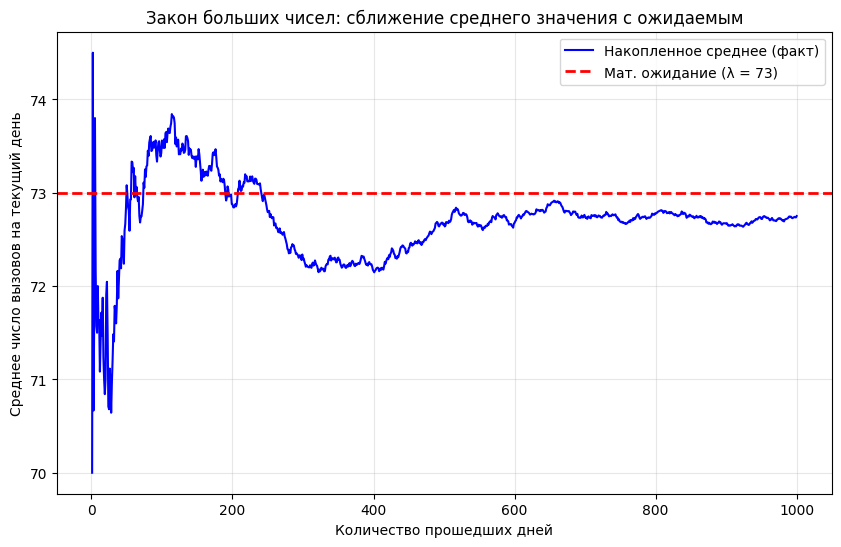

--- Результаты за 1000 дней ---
Финальное среднее значение: 72.7500
Теоретическое значение λ:   73
Итоговая погрешность:      0.2500


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# 1. ПАРАМЕТРЫ МОДЕЛИ
λ = 73  # Интенсивность (среднее количество звонков в сутки)
days = 1000  # Длительность эксперимента (количество испытаний)
np.random.seed(42)  # Фиксируем генератор случайных чисел для повторяемости результата

# 2. ГЕНЕРАЦИЯ ДАННЫХ
# Создаем массив 'calls', где каждый элемент — случайное число звонков в отдельный день
# Распределение Пуассона идеально подходит для моделирования потока событий
calls = poisson.rvs(size=days, mu=λ)

# 3. ВЫЧИСЛЕНИЕ НАКОПЛЕННОГО СРЕДНЕГО (Суть ЗБЧ)
# np.cumsum считает прогрессивную сумму: [a, a+b, a+b+c, ...]
# np.arange создает последовательность дней: [1, 2, 3, ..., 1000]
# Деление суммы на номер дня дает нам среднее значение на конкретный момент времени
sr = np.cumsum(calls) / np.arange(1, days + 1)

# 4. ВИЗУАЛИЗАЦИЯ
plt.figure(figsize=(10, 6))

# Рисуем график изменения среднего значения со временем
plt.plot(np.arange(1, days + 1), sr, label='Накопленное среднее (факт)', color='blue')

# Рисуем горизонтальную линию теоретического ожидания (λ)
plt.axhline(y=λ, color='red', linestyle='--', linewidth=2, label=f'Мат. ожидание (λ = {λ})')

# Оформление графика
plt.xlabel('Количество прошедших дней')
plt.ylabel('Среднее число вызовов на текущий день')
plt.title('Закон больших чисел: сближение среднего значения с ожидаемым')
plt.legend()
plt.grid(True, alpha=0.3) # Добавляем полупрозрачную сетку
plt.show()

# 5. ВЫВОД СТАТИСТИКИ В КОНСОЛЬ
print(f"--- Результаты за {days} дней ---")
print(f"Финальное среднее значение: {sr[-1]:.4f}")
print(f"Теоретическое значение λ:   {λ}")
print(f"Итоговая погрешность:      {abs(sr[-1] - λ):.4f}")

Мат.ожидание = 73.0


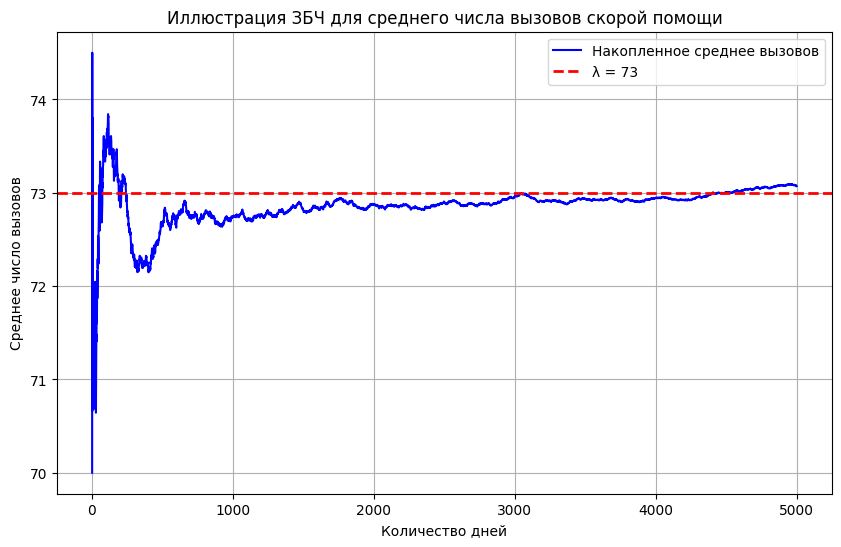

Среднее за 5000 дней: 73.0714
Ожидаемое значение λ: 73
Отклонение: 0.0714
 
[70 79 63 ... 62 60 63]
[70.         74.5        70.66666667 ... 73.07603041 73.07341468
 73.0714    ]


In [ ]:
from numpy import mean, exp

λ = 73 #E(x)=λ
print(f'Мат.ожидание = {poisson(mu=λ).mean()}')

np.random.seed(42)
days=1000
calls = poisson.rvs(size=days, mu=73)
#деление накопленной суммы на номер дня в массиве показывает увелечение среднего арифмитического случайных величин, день 1 = x1/1, день 2 = (x1+x2)/2 и т.д.
sr = np.cumsum(calls)/np.arange(1, days+1)
#при увеличении числа испытаний (дней) среднее арифметическое случайных величин (количества вызовов) стремится к математическому ожиданию

plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, days + 1), sr, label='Накопленное среднее вызовов', color='blue')
plt.axhline(y=λ, color='red', linestyle='--', linewidth=2, label=f'λ = {λ}')
plt.xlabel('Количество дней')
plt.ylabel('Среднее число вызовов')
plt.title('Иллюстрация ЗБЧ для среднего числа вызовов скорой помощи')
plt.legend()
plt.grid(True)
plt.show()

print(f"Среднее за {days} дней: {sr[-1]:.4f}")
print(f"Ожидаемое значение λ: {λ}")
print(f"Отклонение: {abs(sr[-1] - λ):.4f}")
print(' ')
print(calls)
print(sr)